# **CA 3 - Part1, LLMs Spring 2025**

- **Name:** Erfan Shahabi

---
#### Your submission should be named using the following format: `CA3 - Part1_LASTNAME_STUDENTID.ipynb`.

---

##### *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says ```Your Answer Here``` with your actual answer.

- There is no penalty for using AI assistance on this homework as long as you fully disclose it in the final cell of this notebook (this includes storing any prompts that you feed to large language models). That said, anyone caught using AI assistance without proper disclosure will receive a zero on the assignment (we have several automatic tools to detect such cases). We're literally allowing you to use it with no limitations, so there is no reason to lie!

---

##### *Academic honesty*

- We will audit the Colab notebooks from a set number of students, chosen at random. The audits will check that the code you wrote actually generates the answers in your notebook. If you turn in correct answers on your notebook without code that actually generates those answers, we will consider this a serious case of cheating.

- We will also run automatic checks of Colab notebooks for plagiarism. Copying code from others is also considered a serious case of cheating.

---

If you have any further questions or concerns, contact the TAs via email:

# Import libraries and Dependencies

In [1]:
!pip install datasets
!pip install transformers

In [2]:
# Write Your Code Here
from datasets import load_dataset
import transformers


# 🧩Part 1: Judgement Strategies in LLM as a Judge

## 1.1 Load Dataset

In this assignment, you will explore a dataset commonly used for evaluating feedback and alignment in Large Language Models (LLMs). The goal is to help you become familiar with how such datasets are structured and how to extract meaningful information from them.

 use the 🤗 datasets library to download the following dataset:

> `prometheus-eval/Feedback-Bench`

> Link: https://huggingface.co/datasets/prometheus-eval/Feedback-Bench

> paper: https://arxiv.org/abs/2310.08491



In [13]:
pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12

In [3]:
# Write Your Code Here
ds = load_dataset("prometheus-eval/Feedback-Bench")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

(…)-00000-of-00001-eddf1add30d20be1.parquet:   0%|          | 0.00/7.24M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [4]:
print(ds)
print(ds['train'].features)
ds['train'][0]

DatasetDict({
    train: Dataset({
        features: ['orig_instruction', 'orig_score3_description', 'orig_score4_description', 'output', 'orig_response', 'orig_reference_answer', 'orig_feedback', 'orig_score1_description', 'orig_score', 'orig_criteria', 'orig_score2_description', 'instruction', 'orig_score5_description', 'input', 'messages', '__index_level_0__'],
        num_rows: 1000
    })
})
{'orig_instruction': Value(dtype='string', id=None), 'orig_score3_description': Value(dtype='string', id=None), 'orig_score4_description': Value(dtype='string', id=None), 'output': Value(dtype='string', id=None), 'orig_response': Value(dtype='string', id=None), 'orig_reference_answer': Value(dtype='string', id=None), 'orig_feedback': Value(dtype='string', id=None), 'orig_score1_description': Value(dtype='string', id=None), 'orig_score': Value(dtype='string', id=None), 'orig_criteria': Value(dtype='string', id=None), 'orig_score2_description': Value(dtype='string', id=None), 'instruction': Valu

{'orig_instruction': 'Imagine a scenario where an individual from the UK is in the United States for a vacation. However, they are struggling to understand the local dialects, accents, and expressions used by the people there. They are also finding it hard to convey their intended message as their phrases and expressions, heavily influenced by their regional factors, are often misunderstood. What steps or strategies can this individual employ to improve their understanding and communication in such a scenario?',
 'orig_score3_description': 'The model demonstrates a fair understanding of local dialects, accents, and vernaculars, yet at times misinterprets the context.',
 'orig_score4_description': 'The model exhibits a robust understanding of diverse local dialects, accents, and idiomatic expressions, and seldom misreads the context.',
 'output': 'The response provides a glimpse into some methods an individual might use to navigate regional dialects, accents, and local expressions in th

In [5]:
# Write Your Code Here
df = ds['train'].to_pandas()
print(df.dtypes)

orig_instruction           object
orig_score3_description    object
orig_score4_description    object
output                     object
orig_response              object
orig_reference_answer      object
orig_feedback              object
orig_score1_description    object
orig_score                 object
orig_criteria              object
orig_score2_description    object
instruction                object
orig_score5_description    object
input                      object
messages                   object
__index_level_0__           int64
dtype: object


## 1.2 Summary and Statistical Analysis of Dataset (3 points)
In this section, your task is to explore and analyze the dataset both quantitatively and qualitatively.

* Describe what the column represents.

* Identify columns with integer or numerical values.

* Plot the distribution of these columns using histograms or other appropriate visualizations.

In [6]:
# Write Your Code Here
df['orig_score']

,orig_score
0,2
1,1
2,5
3,1
4,1
...,...
995,5
996,4
997,2
998,3


In [7]:
import pandas as pd
df['orig_score_num'] = pd.to_numeric(df['orig_score'], errors = 'coerce')
print(df['orig_score_num'])

0      2
1      1
2      5
3      1
4      1
      ..
995    5
996    4
997    2
998    3
999    4
Name: orig_score_num, Length: 1000, dtype: int64


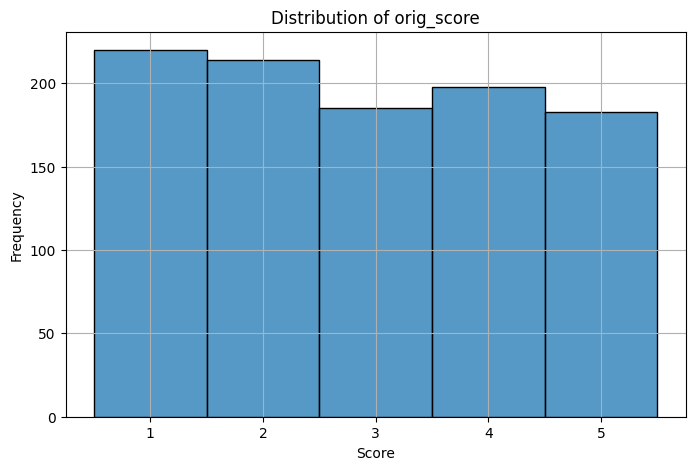

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['orig_score_num'], bins=5, kde=False, discrete=True)
plt.title("Distribution of orig_score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

`# WRITE YOUR ANSWER HERE`

The columns in this dataset contain information such as the instruction given to the model, the model’s initial responses, the reference answer, the actual score assigned to the model’s response, descriptions of the scoring levels, and so on.
The orig_score column includes the scores given to the model’s responses. By default, these scores were stored as object type, so I converted them to float format and saved them in a new column called orig_score_num.
I also plotted the score distribution for this dataset, which is shown above. The histogram indicates that the distribution of scores is relatively balanced, with only slight differences among them. This suggests that the model’s responses are not biased toward a particular score.

## 1.3 Load Phi-3-3.8B model

Use the Hugging Face transformers library to load the model and tokenizer:

Model: https://huggingface.co/microsoft/Phi-3-mini-4k-instruct


In [9]:
# Write Your Code Here

from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct", trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained("microsoft/Phi-3-mini-4k-instruct", trust_remote_code=True, device_map = "auto")


tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

## 1.4 Phi Judgemnt Performance Evaluation (23 points)

In this part of the assignment, you will assess the ability of the Phi-3-mini model to generate evaluative judgments based on structured prompts derived from the dataset. Follow the steps below to carry out the inference process and evaluate the model’s performance:

**1. Prompt Construction:**


Use relevant columns from the dataset (e.g., orig_instruction,orig_criteria, etc.) to construct informative prompts that the model can respond to meaningfully.


**2. Model Inference:**

Select a random sample of 50 entries from the dataset. For each entry, feed the constructed prompt into the Phi model and generate a corresponding judgment and score.

*Don't forget applying chat template 😊*

**3. Output Parsing:**

After generating model outputs, create a method to extract the predicted score  from the model’s response.


**4. Metric Selection and Performance Analysis:**

Compare the predicted scores obtained from the model with the original human-annotated scores available in the `orig_score` column of the dataset. This step will help you measure how well the model’s outputs align with refrence judge.

### 1.4.1 Prompt Construction (2 points)

In [18]:
# Write Your Code Here
def build_prompt(row):
    instruction = row['orig_instruction']
    criteria = row['orig_criteria']
    model_response = row['orig_response']
    reference_answer = row['orig_reference_answer']

    chat_messages = [
        {
            "role": "system",
            "content": (
                "You are an expert evaluator. Rate the following response based on the given criterion."
            )
        },
        {
            "role": "user",
            "content": f"Question: {instruction}"
        },
        {
            "role": "user",
            "content": f"Evaluation Criterion: {criteria}"
        },
        {
            "role": "user",
            "content": f"Reference Answer: {reference_answer}"
        },
        {
            "role": "user",
            "content": f"System Answer: {model_response}"
        },
        {
            "role": "user",
            "content": (
                "How well does the response satisfy the criterion?"
                "Give a score from 1 (very poor) to 5 (excellent)."
                "I don't need explanation, please just give me the score.\n\n"
                "Score (1-5):"
            )
        }
    ]
    return chat_messages

sample_df = df[['orig_instruction', 'orig_response', 'orig_reference_answer','orig_criteria', 'orig_score_num']].dropna()
sample_df = sample_df.sample(n=50, random_state=42).reset_index(drop=True)

sample_df['prompt'] = sample_df.apply(build_prompt, axis=1)
sample_df["prompt_string"] = sample_df["prompt"].apply(
    lambda messages: tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
)
for i, row in sample_df.iterrows():
    print(f"\n---- Prompt {i} ----\n{row['prompt_string']}\n")


---- Prompt 0 ----
<|system|>
You are an expert evaluator. Rate the following response based on the given criterion.<|end|>
<|user|>
Question: As an AI, I've been working with a user who is going through a tough time. He recently lost his job and is struggling to cope with the change. He often talks about feelings of worthlessness and fear for the future. He's also mentioned that he feels isolated as he's unable to share his feelings with his family or friends. How can I provide support to this user in a way that demonstrates understanding, empathy, and encouragement?<|end|>
<|user|>
Evaluation Criterion: Can the model recognize and adequately respond to emotionally charged situations? Does it provide empathy, sympathy, or encouragement when needed?<|end|>
<|user|>
Reference Answer: It is certainly a difficult time for the user and as an AI, it is my responsibility to provide support and encouragement. I can suggest him to view this as a phase of life that will pass, and not a reflect

In [11]:
import torch
model.eval()
def generate_score(prompt, max_new_tokens = 10):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
  with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        temperature = 0.0,
        pad_token_id = tokenizer.eos_token_id,
        use_cache = False
    )
  response = tokenizer.decode(outputs[0], skip_special_tokens = True)
  return response

### 1.4.2 Model Inference (5 points)

In [21]:
# Write Your Code Here
sample_df['model_output'] = sample_df['prompt_string'].apply(generate_score)

for i, row in sample_df.iterrows():
    print(f"\n--- Prompt {i} ---")
    print(f"Prompt:\n{row['prompt_string']}")
    print(f"\nModel Output:\n{row['model_output']}")
    print(f"\nTrue Score: {row['orig_score_num']}")
    print("=" * 80)


--- Prompt 0 ---
Prompt:
<|system|>
You are an expert evaluator. Rate the following response based on the given criterion.<|end|>
<|user|>
Question: As an AI, I've been working with a user who is going through a tough time. He recently lost his job and is struggling to cope with the change. He often talks about feelings of worthlessness and fear for the future. He's also mentioned that he feels isolated as he's unable to share his feelings with his family or friends. How can I provide support to this user in a way that demonstrates understanding, empathy, and encouragement?<|end|>
<|user|>
Evaluation Criterion: Can the model recognize and adequately respond to emotionally charged situations? Does it provide empathy, sympathy, or encouragement when needed?<|end|>
<|user|>
Reference Answer: It is certainly a difficult time for the user and as an AI, it is my responsibility to provide support and encouragement. I can suggest him to view this as a phase of life that will pass, and not a r

### 1.4.3 Extract Score (Output Parsing) (5 points)

In [22]:
# Write Your Code Here
import re

def extract_score(text, valid_range=(1, 5)):
    if not isinstance(text, str):
        return None

    matches = re.findall(r"\b\d+\b", text)


    for num_str in reversed(matches):
        num = int(num_str)
        if valid_range[0] <= num <= valid_range[1]:
            return num

    return None

sample_df['model_score'] = sample_df['model_output'].apply(extract_score)
for i, row in sample_df.iterrows():
  print(f"\n--- output {i} ---\m{row['model_output']}\n")
  print(f"model score: {row['model_score']}")
  print(f"True Score:     {row['orig_score_num']}")
  print("="*80)


--- output 0 ---\mYou are an expert evaluator. Rate the following response based on the given criterion. Question: As an AI, I've been working with a user who is going through a tough time. He recently lost his job and is struggling to cope with the change. He often talks about feelings of worthlessness and fear for the future. He's also mentioned that he feels isolated as he's unable to share his feelings with his family or friends. How can I provide support to this user in a way that demonstrates understanding, empathy, and encouragement? Evaluation Criterion: Can the model recognize and adequately respond to emotionally charged situations? Does it provide empathy, sympathy, or encouragement when needed? Reference Answer: It is certainly a difficult time for the user and as an AI, it is my responsibility to provide support and encouragement. I can suggest him to view this as a phase of life that will pass, and not a reflection of his worth. I can tell him that it's okay to feel upse

### 1.4.4 Metric Selection and Performance Analysis (11 points)

Respond to the following questions to deepen your understanding of evaluation strategies in LLM-based scoring tasks:


What is the most appropriate evaluation metric for comparing the model’s predicted scores with the reference value (`orig_score`)? Consider the type of scores (e.g., continuous, ordinal, or categorical) when making your choice. (3 points)

Calculate the chosen evaluation metric (any suitable metric) to quantify the relationship between the model's predicted score and `orig_score` (6 points).

Is accuracy a suitable metric in this context? Why or why not? (2 points)







`# WRITE YOUR ANSWER HERE`

In [23]:
# Write Your Code Here
def match_or_miss(true, pred):
    if pd.isna(pred):
        return False
    return true == pred

sample_df['is_correct'] = sample_df.apply(lambda row: match_or_miss(row['orig_score_num'], row['model_score']), axis=1)

accuracy = sample_df['is_correct'].mean()
print(f"Adjusted Accuracy (counts NaN as wrong): {accuracy:.2%}")

Adjusted Accuracy (counts NaN as wrong): 44.00%


In [24]:
from sklearn.metrics import mean_absolute_error

valid_rows = sample_df.dropna(subset=["model_score"])

mae = mean_absolute_error(valid_rows["orig_score_num"], valid_rows["model_score"])
print(f"MAE: {mae:.3f}")

MAE: 0.740


`# WRITE YOUR ANSWER HERE`

To evaluate the scores generated by the model, I calculated two metrics. The first metric is accuracy. In this case, any instance where the model failed to generate a score or the generated response did not contain a score was considered incorrect. The percentage of cases where the model produced the correct score (i.e., matching the reference score) was calculated to be 44%. This means the model was able to assign the correct score in 44% of the cases.

I also used the Mean Absolute Error (MAE) metric. This metric computes the absolute difference between the model’s predicted score and the reference score for each response, and then calculates the average of those differences. The closer the MAE is to 0, the more similar the model’s scores are to the reference scores. In this case, the MAE was 0.74, indicating a moderate level of agreement between the model’s scores and the reference.

## 1.5 Alternative Evaluation Strategies (15 points)

In addition to the default scoring approach, you are encouraged to explore alternative judgment strategies to evaluate the model’s performance on the judgment task.


---

### Examples of Alternative Approaches

#### Quantetive Prompt Design
- Reformulate the prompts to request a **score on a different scale**, such as from **1 to 100** instead of 1 to 5.
- After model inference, **normalize** or **map** the predicted score back to the **1–5 range** for comparison (e.g., using simple scaling or binning).

#### Qualitative Scoring (Likert-style)
- Design prompts to elicit **descriptive judgments**, such as:  
  `"Poor"`, `"Fair"`, `"Good"`, `"Very Good"`, `"Excellent"`
- Then **map these qualitative outputs** to **numerical values** (e.g., 1 to 5) to enable metric-based evaluation.



In [25]:
def build_prompt2(row):
    instruction = row['orig_instruction']
    criteria = row['orig_criteria']
    model_response = row['orig_response']
    reference_answer = row.get('orig_reference_answer', '')

    chat_messages = [
        {
            "role": "system",
            "content": (
                "You are an expert evaluator. Rate the system answer based on how well it satisfies the criterion."
            )
        },
        {
            "role": "user",
            "content": f"Question: {instruction}"
        },
        {
            "role": "user",
            "content": f"Evaluation Criterion: {criteria}"
        },
        {
            "role": "user",
            "content": f"Reference Answer: {reference_answer}"
        },
        {
            "role": "user",
            "content": f"System Answer: {model_response}"
        },
        {
            "role": "user",
            "content": (
                "Please rate the system answer's quality from 1 (very poor) to 100 (excellent), based only on the evaluation criterion.\n"
                "Do not explain your answer. Just return the score.\n\n"
                "Score (1-100):"
            )
        }
    ]
    return chat_messages


sample_df['prompt2'] = sample_df.apply(build_prompt2, axis=1)
sample_df["prompt_string2"] = sample_df["prompt2"].apply(
    lambda messages: tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
)


sample_df['model_output2'] = sample_df['prompt_string2'].apply(generate_score)


for i, row in sample_df.iterrows():
    print(f"\n--- Prompt {i} ---\n{row['prompt_string2']}")
    print(f"Model Output: {row['model_output2']}")
    print(f"True Score:   {row['orig_score_num']}")
    print("="*80)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(



--- Prompt 0 ---
<|system|>
You are an expert evaluator. Rate the system answer based on how well it satisfies the criterion.<|end|>
<|user|>
Question: As an AI, I've been working with a user who is going through a tough time. He recently lost his job and is struggling to cope with the change. He often talks about feelings of worthlessness and fear for the future. He's also mentioned that he feels isolated as he's unable to share his feelings with his family or friends. How can I provide support to this user in a way that demonstrates understanding, empathy, and encouragement?<|end|>
<|user|>
Evaluation Criterion: Can the model recognize and adequately respond to emotionally charged situations? Does it provide empathy, sympathy, or encouragement when needed?<|end|>
<|user|>
Reference Answer: It is certainly a difficult time for the user and as an AI, it is my responsibility to provide support and encouragement. I can suggest him to view this as a phase of life that will pass, and not 

In [26]:
import re
def extract_score_100(text, valid_range=(1, 100)):
    if not isinstance(text, str):
        return None

    matches = re.findall(r"\b\d+\b", text)


    for num_str in reversed(matches):
        num = int(num_str)
        if valid_range[0] <= num <= valid_range[1]:
            return num

    return None
def map_100_to_5(score):
    if pd.isna(score):
        return None
    score = int(score)
    if score <= 20:
        return 1
    elif score <= 40:
        return 2
    elif score <= 60:
        return 3
    elif score <= 80:
        return 4
    else:
        return 5
sample_df['model_score2'] = sample_df['model_output2'].apply(extract_score_100)
sample_df['predicted_score_normal'] = sample_df['model_score2'].apply(map_100_to_5)

In [27]:
# Write Your Code Here
for i, row in sample_df.iterrows():
  print(f"\n--- output {i} ---\m{row['model_output2']}\n")
  print(f"model score: {row['predicted_score_normal']}")
  print(f"True Score:     {row['orig_score_num']}")
  print("="*80)


--- output 0 ---\mYou are an expert evaluator. Rate the system answer based on how well it satisfies the criterion. Question: As an AI, I've been working with a user who is going through a tough time. He recently lost his job and is struggling to cope with the change. He often talks about feelings of worthlessness and fear for the future. He's also mentioned that he feels isolated as he's unable to share his feelings with his family or friends. How can I provide support to this user in a way that demonstrates understanding, empathy, and encouragement? Evaluation Criterion: Can the model recognize and adequately respond to emotionally charged situations? Does it provide empathy, sympathy, or encouragement when needed? Reference Answer: It is certainly a difficult time for the user and as an AI, it is my responsibility to provide support and encouragement. I can suggest him to view this as a phase of life that will pass, and not a reflection of his worth. I can tell him that it's okay t

In [28]:
# Write Your Code Here
# Write Your Code Here
def match_or_miss(true, pred):
    if pd.isna(pred):
        return False
    return true == pred

sample_df['is_correct'] = sample_df.apply(lambda row: match_or_miss(row['orig_score_num'], row['predicted_score_normal']), axis=1)

accuracy = sample_df['is_correct'].mean()
print(f"Adjusted Accuracy (counts NaN as wrong): {accuracy:.2%}")

Adjusted Accuracy (counts NaN as wrong): 22.00%


In [29]:
# Write Your Code Here
from sklearn.metrics import mean_absolute_error


valid_rows = sample_df.dropna(subset=["predicted_score_normal"])

mae = mean_absolute_error(valid_rows["orig_score_num"], valid_rows["predicted_score_normal"])
print(f"MAE: {mae:.3f}")

MAE: 1.720


## Conclusion

In this section, I also explored an alternative approach where the model assigns scores on a scale from 1 to 100 instead of 1 to 5. Since the scores are expected to be discrete, I applied a simple normalization technique to map them back.

However, as the evaluation metrics from the previous step indicate, the model performed worse using this method. The accuracy dropped to 22%, essentially halving, and the Mean Absolute Error (MAE) increased to 1.72, suggesting that the difference between the model’s predicted scores and the reference scores has grown.

In my opinion, this decline in performance is due to the larger scoring range (1 to 100). After normalization—and considering that the final scores must be integers—this wider range likely introduced more variability and reduced the precision of the model’s predicted scores.


# 🧩 Part 2: Creating Preference Data Using LLM as Judge

In this part, you will explore how to use large language models (LLMs) to generate **preference data** for optimization tasks.

We will compare two models:

- `Qwen/Qwen1.5-1.8B-Chat`
- `stabilityai/stablelm-2-zephyr-1_6b`

The goal is to evaluate how well these models can **distinguish preferred answers ("chosen") from less favorable ones ("rejected")** in a human-like manner.

---

## 2.1 Download the Models and Dataset

- Load the following two models from Hugging Face:
  - `Qwen/Qwen1.5-1.8B-Chat`
  - `stabilityai/stablelm-2-zephyr-1_6b`

- Download the dataset:  
  [`HumanLLMs/Human-Like-DPO-Dataset`](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset)

---

In [3]:
!pip install -U datasets fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12

In [10]:
# Write Your Code Here
from transformers import AutoModelForCausalLM, AutoTokenizer

model_ids = [
    "Qwen/Qwen1.5-1.8B-Chat",
    "stabilityai/stablelm-2-zephyr-1_6b"
]

models = {}
tokenizers = {}

for model_id in model_ids:
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True, device_map="auto")
    model.eval()
    models[model_id] = model
    tokenizers[model_id] = tokenizer


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


In [1]:
# Write Your Code Here
from datasets import load_dataset

dpo_dataset = load_dataset("HumanLLMs/Human-Like-DPO-Dataset")
dpo_dataset['train']

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

data.json:   0%|          | 0.00/28.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10884 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 10884
})

## 2.2 Dataset Exploration (1 point)


- Analyze the `HumanLLMs/Human-Like-DPO-Dataset`.
  - Describe the dataset structure and columns.

- **Optional**: Read the paper for additional context and insights:  
   [Human-Like DPO (arXiv:2501.05032)](https://arxiv.org/pdf/2501.05032)



`# WRITE YOUR ANSWER HERE`

The HumanLLMs/Human-Like-DPO-Dataset is designed for preference modeling and Direct Preference Optimization (DPO), which is a strategy to fine-tune language models to prefer better outputs.
prompt

The input instruction or question given to the model. It defines the context for which responses are generated.

chosen

The preferred response selected by a human annotator or preference model. It represents the better of the two responses.

rejected

The less preferred response. It might be less helpful, less accurate, or poorly aligned with the prompt.


## 2.3 Judging Setup (3 points)

- Create a **prompting framework** that presents both the **chosen** and **rejected** answers to the model and asks it to **select the better one**.


Example prompt structure:
> "Here is a prompt and two responses. Please choose the better response based on helpfulness, relevance, and coherence.  
>  
> Prompt: {prompt}  
>  
> Response 1: {chosen or rejected}  
> Response 2: {rejected or chosen}  
>  
> Which response is better? Reply with 'Answer 1' or 'Answer 2'."
---

In [12]:
import random
def build_judging_prompt(example):
    prompt_text = example['prompt']
    chosen = example['chosen']
    rejected = example['rejected']

    responses = [(chosen, 'chosen'), (rejected, 'rejected')]
    random.shuffle(responses)

    response_1, label_1 = responses[0]
    response_2, label_2 = responses[1]

    correct_answer = 'Answer 1' if label_1 == 'chosen' else 'Answer 2'

    judging_prompt = f"""Here is a prompt and two responses. Please choose the better response based on helpfulness, relevance, and coherence.

Prompt: {prompt_text}

Response 1: {response_1}
Response 2: {response_2}

Which response is better? Just Choose 'Answer 1' or 'Answer 2'NO MORE."""

    chat_messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": judging_prompt}
    ]

    return {
        "prompt": prompt_text,
        "chosen": chosen,
        "rejected": rejected,
        "correct_answer": correct_answer,
        "response_1_type": label_1,
        "response_2_type": label_2,
        "judging_prompt": judging_prompt,
        "chat_messages": chat_messages,
    }

## 2.4 Model Comparison (10 points)

- Run inference using both models on a **sample of the dataset** (e.g., 200–500 instances from dataset). (2 points)
- Compare each model's judgments to the **ground truth** (i.e., whether it preferred the "chosen" response). (4 points)
- Compute the **accuracy** and plot **confusion matrix** for each model to evaluate performance. (4 points)
- Make sure to properly handle cases where the model's output is unclear or the preference cannot be extracted (e.g., skip or categorize as "unkowned").

In [14]:
# Write Your Code Here

train_data = dpo_dataset["train"]
train_data = dpo_dataset["train"]
judging_data = train_data.shuffle(seed=42).select(range(400)).map(build_judging_prompt)



In [7]:
from tqdm import tqdm
import torch

def run_model_on_prompts(model, tokenizer, chat_messages_list, max_tokens=64):
    """
    Runs inference using chat-based prompts.

    Parameters:
    - chat_messages_list: list of `chat_messages`, each a list of {"role", "content"}
    """
    outputs = []

    for chat_messages in tqdm(chat_messages_list, desc="Running model..."):
        # Apply chat template
        input_ids = tokenizer.apply_chat_template(
            chat_messages,
            return_tensors="pt",
            truncation=True,
            add_generation_prompt=True
        ).to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                input_ids,
                max_new_tokens=max_tokens,
                do_sample=False,
                temperature=0.0,
                eos_token_id=tokenizer.eos_token_id
            )

        output = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        outputs.append(output)

    return outputs

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm
import re


import re

def extract_answer(output):
    if not isinstance(output, str):
        return "Unknown"

    lines = output.strip().splitlines()[::-1]

    for line in lines:
        line = line.strip().lower()


        if "which response is better?" in line or "just reply with 'answer 1' or 'answer 2'" in line:
            return "Unknown"


        match = re.search(r"\banswer\s*(1|2)\b", line)
        if match:
            return f"Answer {match.group(1)}"

    return "Unknown"

def compare_predictions(outputs, judging_data):
    preds = []
    truths = []
    for out, ex in zip(outputs, judging_data):
        pred = extract_answer(out)
        truth = ex["correct_answer"]
        preds.append(pred)
        truths.append(truth)
    return preds, truths

def evaluate_model(preds, truths, title="Confusion Matrix"):

    filtered = [(p, t) for p, t in zip(preds, truths) if p != "Unknown"]
    if not filtered:
        print("No valid predictions.")
        return

    y_pred, y_true = zip(*filtered)

    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.2%} on {len(y_pred)} samples")

    cm = confusion_matrix(y_true, y_pred, labels=["Answer 1", "Answer 2"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Answer 1", "Answer 2"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

Running model...: 100%|██████████| 400/400 [04:35<00:00,  1.45it/s]


Accuracy: 69.75% on 400 samples


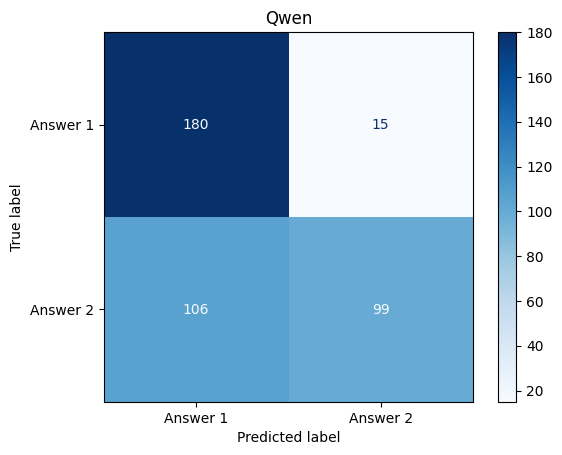

Running model...:   0%|          | 0/400 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:100257 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Running model...:   0%|          | 1/400 [00:02<15:56,  2.40s/it]The attention mask and the pad token id were not set. As a consequence, you may observe u

Accuracy: 73.22% on 351 samples


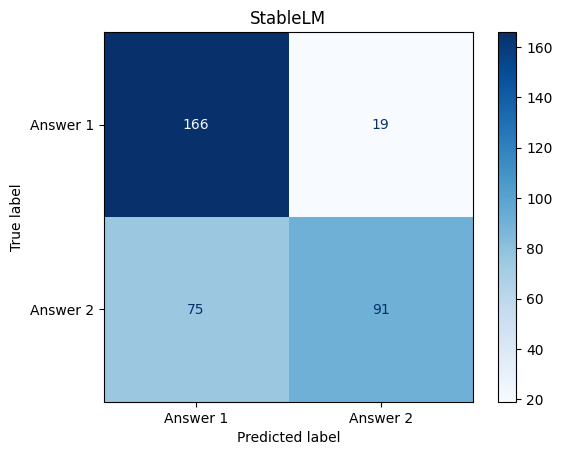

In [15]:
# Qwen evaluation
qwen_model = models["Qwen/Qwen1.5-1.8B-Chat"]
qwen_tokenizer = tokenizers["Qwen/Qwen1.5-1.8B-Chat"]

qwen_outputs = run_model_on_prompts(
    qwen_model, qwen_tokenizer,
    [x["chat_messages"] for x in judging_data]
)

qwen_preds, qwen_truths = compare_predictions(qwen_outputs, judging_data)
evaluate_model(qwen_preds, qwen_truths, title="Qwen")

# StableLM evaluation
zephyr_model = models["stabilityai/stablelm-2-zephyr-1_6b"]
zephyr_tokenizer = tokenizers["stabilityai/stablelm-2-zephyr-1_6b"]

zephyr_outputs = run_model_on_prompts(
    zephyr_model, zephyr_tokenizer,
    [x["chat_messages"] for x in judging_data]
)

zephyr_preds, zephyr_truths = compare_predictions(zephyr_outputs, judging_data)
evaluate_model(zephyr_preds, zephyr_truths, title="StableLM")

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = [1 if x == "Answer 1" else 0 for x in qwen_truths]
y_pred = [1 if x == "Answer 1" else 0 for x in qwen_preds]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (Answer 1 as positive class):")
print(classification_report(y_true, y_pred, target_names=["Answer 2", "Answer 1"]))

Confusion Matrix:
[[ 99 106]
 [ 15 180]]

Classification Report (Answer 1 as positive class):
              precision    recall  f1-score   support

    Answer 2       0.87      0.48      0.62       205
    Answer 1       0.63      0.92      0.75       195

    accuracy                           0.70       400
   macro avg       0.75      0.70      0.68       400
weighted avg       0.75      0.70      0.68       400



In [17]:
y_true_z = [1 if x == "Answer 1" else 0 for x in zephyr_truths]
y_pred_z = [1 if x == "Answer 1" else 0 for x in zephyr_preds]


print("Confusion Matrix:")
print(confusion_matrix(y_true_z, y_pred_z))
print("\nStableLM Classification Report:")
print(classification_report(y_true_z, y_pred_z, target_names=["Answer 2", "Answer 1"]))

Confusion Matrix:
[[130  75]
 [ 29 166]]

StableLM Classification Report:
              precision    recall  f1-score   support

    Answer 2       0.82      0.63      0.71       205
    Answer 1       0.69      0.85      0.76       195

    accuracy                           0.74       400
   macro avg       0.75      0.74      0.74       400
weighted avg       0.75      0.74      0.74       400



## Explanation

As you can see, the results, show us that model Qwen generate the Answer token correctely and in the this model result we don't have Unknown tag, this model has better work on identifying answer 1 as you can see this model found the 180 of answer 1s correctly, but the StableLM could find the 166 of that. also Qwen model found more correct answer 2 than StableLM.
If you consider f1 score in confiusion matrix, StableLM model had better performance and I think this is because of the diffrence between precision and recall in these two model results